I've been using detailed closely spaced hex grids (with a vertical spacing of 10m); this may have to be bumped up somewhat to increase speed (by reducing points); I want to see how much difference there is

In [1]:
import pytest
import geopandas as gpd
import json
from pathlib import Path
import sys

sys.path.insert(0, '../../src')

import park_vga

import cProfile
import pstats


In [2]:
TEST_PARK_NAME = "Chapel Allerton Park"

output_folder = "optimisation_test_output"

DATA_DIR = "../../example_datasets/"

dsm_path = "../../tests/test_data_england/DSM"
dtm_path = "../../tests/test_data_england/DTM"

boundaries_file = str(DATA_DIR + 'Leeds_pp_or_g_cmb.geojson')

In [3]:
park_n = park_vga.workflow.find_park_n(TEST_PARK_NAME, boundaries_file)

In [4]:
profiler = cProfile.Profile()
profiler.enable()

In [5]:
results_1 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         return_results=True, save_results=False)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_945491c73c1c
Park ID for file name: leeds_945491c73c1c
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(430885.41992692224, 437280.3589293043), (430885.41992692224, 437631.61221827124), (430544.1449808032, 437631.61221827124), (430544.1449808032, 437280.3589293043)]
Grid refs for corners: ['SE33nw', 'SE33nw', 'SE33nw', 'SE33nw']
Tile name(s): {'SE33nw'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE33nw_DTM_2m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE33nw_FZ_DSM_2m.tif']
Files found for park 1
Created 517 pointy-top hexagons (10m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (176, 171), Height range: -0.0m to 25.1m
Start calculating visibility. This will take a few mins
Calculating visibility 

In [6]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         50864505 function calls (50843792 primitive calls) in 25.420 seconds

   Ordered by: cumulative time
   List reduced from 2844 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    90/68    0.001    0.000   44.995    0.662 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
    91/28    0.000    0.000   25.416    0.908 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
    91/28    0.058    0.001   25.416    0.908 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000   25.410   12.705 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        2    0.000    0.000   25.410   12.705 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        2    0.000    0.000   25.406   12.703 /Users/m

In [7]:
profiler = cProfile.Profile()
profiler.enable()

In [8]:
results_2 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         spacing=12,
                                         return_results=True, save_results=False)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_945491c73c1c
Park ID for file name: leeds_945491c73c1c
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(430885.41992692224, 437280.3589293043), (430885.41992692224, 437631.61221827124), (430544.1449808032, 437631.61221827124), (430544.1449808032, 437280.3589293043)]
Grid refs for corners: ['SE33nw', 'SE33nw', 'SE33nw', 'SE33nw']
Tile name(s): {'SE33nw'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE33nw_DTM_2m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE33nw_FZ_DSM_2m.tif']
Files found for park 1
Created 370 pointy-top hexagons (12m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (176, 171), Height range: -0.0m to 25.1m
Start calculating visibility. This will take a few mins
Calculating visibility 

In [9]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         25294243 function calls (25291273 primitive calls) in 12.927 seconds

   Ordered by: cumulative time
   List reduced from 1278 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    86/65    0.009    0.000   13.077    0.201 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
    87/25    0.001    0.000   12.921    0.517 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
    87/25    0.030    0.000   12.921    0.517 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000   12.915    6.457 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        2    0.000    0.000   12.915    6.457 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        2    0.000    0.000   12.911    6.455 /Users/m

In [10]:
profiler = cProfile.Profile()
profiler.enable()

In [11]:
results_3 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         spacing=15,
                                         return_results=True, save_results=False)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_945491c73c1c
Park ID for file name: leeds_945491c73c1c
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(430885.41992692224, 437280.3589293043), (430885.41992692224, 437631.61221827124), (430544.1449808032, 437631.61221827124), (430544.1449808032, 437280.3589293043)]
Grid refs for corners: ['SE33nw', 'SE33nw', 'SE33nw', 'SE33nw']
Tile name(s): {'SE33nw'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE33nw_DTM_2m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE33nw_FZ_DSM_2m.tif']
Files found for park 1
Created 246 pointy-top hexagons (15m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (176, 171), Height range: -0.0m to 25.1m
Start calculating visibility. This will take a few mins
Calculating visibility 

In [12]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         10509373 function calls (10506803 primitive calls) in 5.886 seconds

   Ordered by: cumulative time
   List reduced from 1266 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    70/48    0.007    0.000    5.955    0.124 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
    71/26    0.002    0.000    5.867    0.226 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
    71/25    0.000    0.000    5.865    0.235 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    5.827    2.914 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        2    0.000    0.000    5.827    2.914 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        2    0.000    0.000    5.823    2.912 /Users/ma

<Axes: >

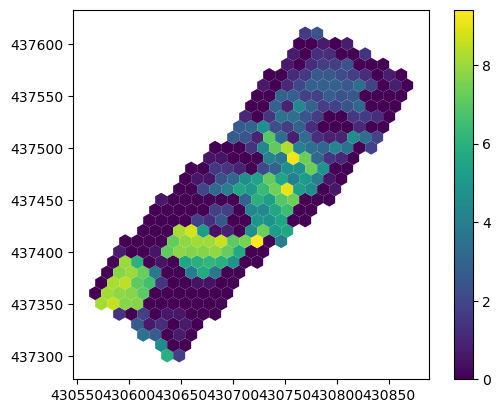

In [13]:
results_1[0].plot(column="visibility_pct", cmap="viridis", legend=True)

<Axes: >

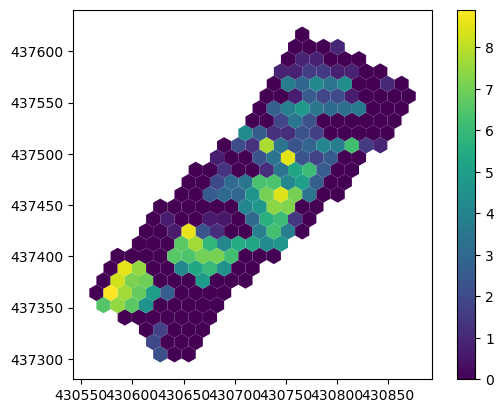

In [14]:
results_2[0].plot(column="visibility_pct", cmap="viridis", legend=True)

<Axes: >

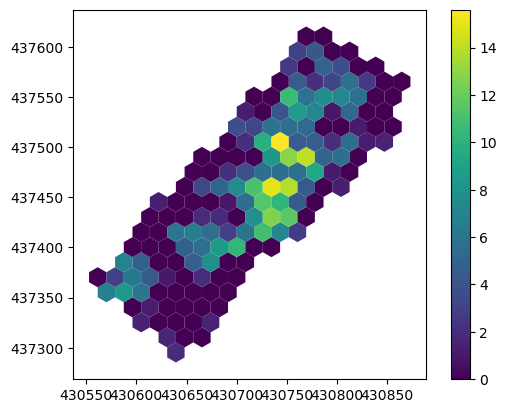

In [15]:
results_3[0].plot(column="visibility_pct", cmap="viridis", legend=True)